년도       2020      2021     2022
폐기물 종류                          
동식물성잔재물   1.0  1.028297  1.14958


~\AppData\Local\Temp\ipykernel_25268\1461852964.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')
~\AppData\Local\Temp\ipykernel_25268\1461852964.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')


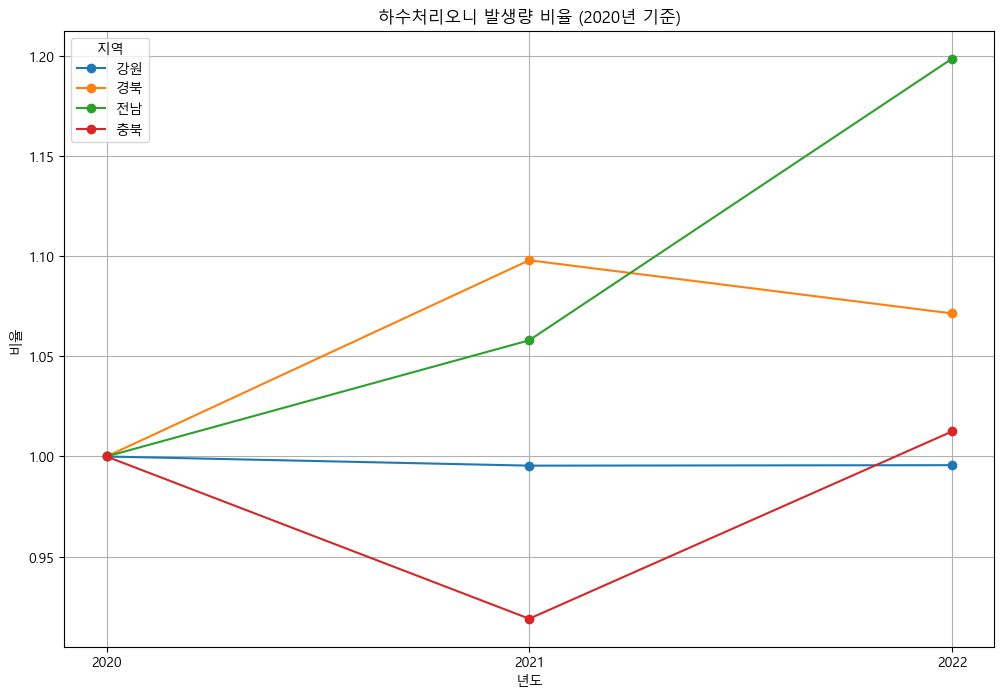

~\AppData\Local\Temp\ipykernel_25268\1461852964.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')


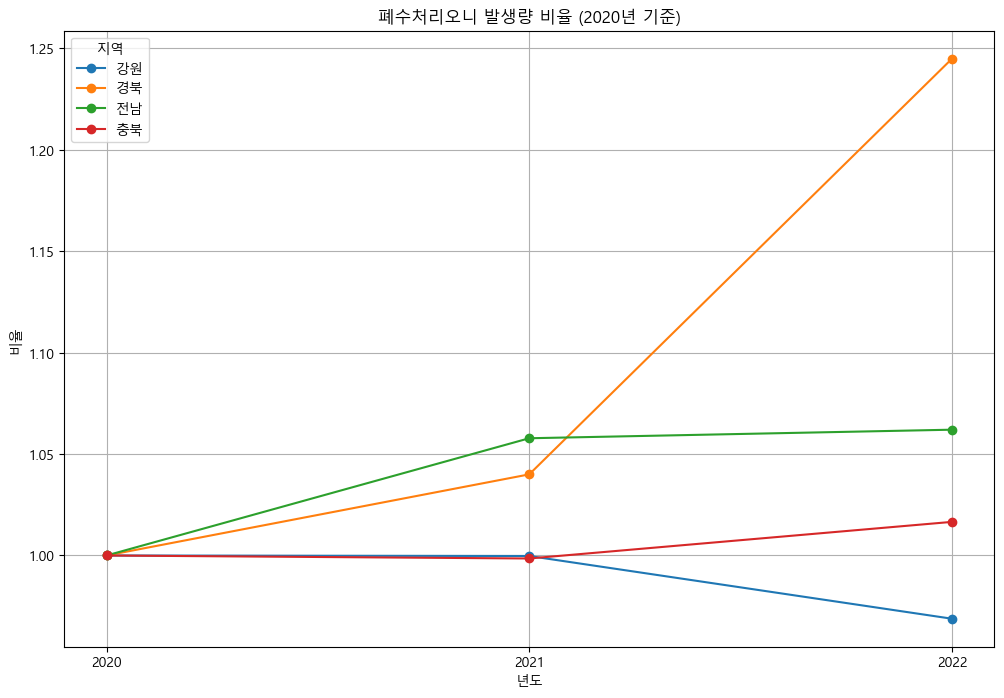

~\AppData\Local\Temp\ipykernel_25268\1461852964.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')


년도  2020      2021      2022
시도                          
강원   1.0  1.028297  1.149580
경북   1.0  0.918719  0.953620
전남   1.0  0.936642  1.019676
충북   1.0  0.794968  0.893697


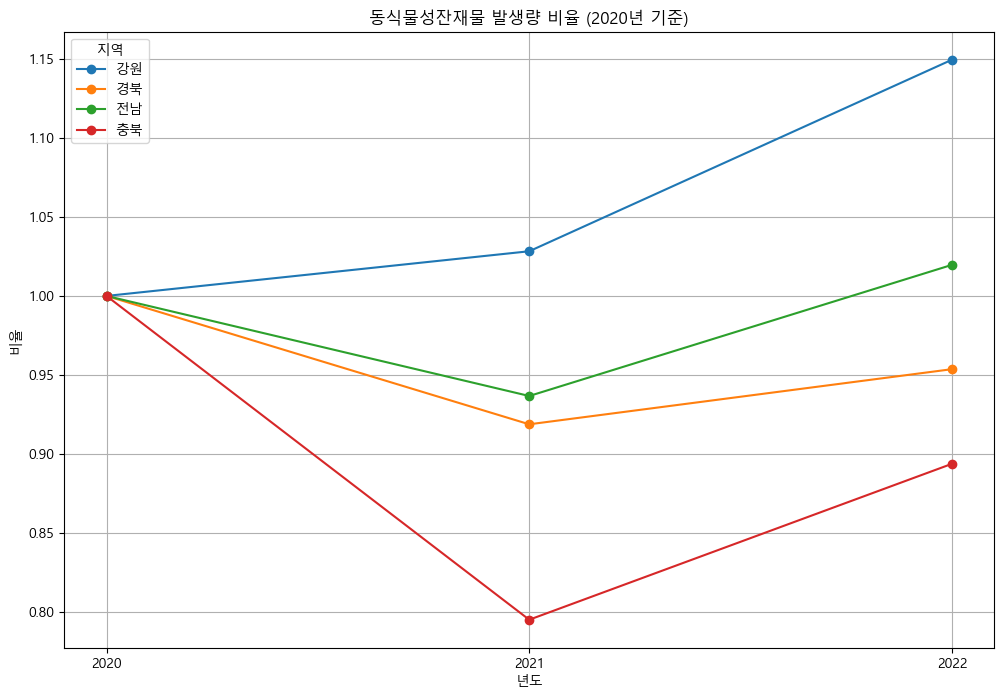

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# CSV 파일 경로
file_path = '../data/새 폴더/폐기물생산량.csv'

# 데이터 로드
data = pd.read_csv(file_path)

# 강원 지역 동식물성잔재물 데이터 필터링 및 비율 계산
def calculate_ratios(data, region, waste_type, years=[2020, 2021, 2022]):
    # 필터링
    data_filtered = data[(data['시도'] == region) & (data['폐기물 종류'] == waste_type) & (data['년도'].isin(years))]
    # 발생량 숫자로 변환
    data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')
    # 피벗 테이블 생성
    data_pivot = data_filtered.pivot(index='폐기물 종류', columns='년도', values='발생량')
    # 비율 계산
    data_pivot_ratio = data_pivot.div(data_pivot[2020], axis=0)
    return data_pivot_ratio

# 하수처리오니 및 폐수처리오니에 대한 비율 계산 및 그래프 그리기
def plot_ratios(data, waste_types, years=[2020, 2021, 2022]):
    for waste_type in waste_types:
        data_filtered = data[(data['폐기물 종류'] == waste_type) & (data['년도'].isin(years))]
        data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')
        data_pivot = data_filtered.pivot(index='시도', columns='년도', values='발생량')
        data_pivot_ratio = data_pivot.div(data_pivot[2020], axis=0)

        plt.figure(figsize=(12, 8))
        for region in data_pivot_ratio.index:
            plt.plot(data_pivot_ratio.columns, data_pivot_ratio.loc[region], marker='o', label=region)

        plt.title(f'{waste_type} 발생량 비율 (2020년 기준)')
        plt.xlabel('년도')
        plt.ylabel('비율')
        plt.legend(title='지역')
        plt.grid(True)
        plt.xticks(years)  # x축의 값을 1단위로 설정
        plt.show()

# 동식물성잔재물에 대한 모든 지역의 비율 계산
def calculate_all_regions_ratios(data, waste_type, years=[2020, 2021, 2022]):
    data_filtered = data[(data['폐기물 종류'] == waste_type) & (data['년도'].isin(years))]
    data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')
    data_pivot = data_filtered.pivot(index='시도', columns='년도', values='발생량')
    data_pivot_ratio = data_pivot.div(data_pivot[2020], axis=0)
    return data_pivot_ratio

# 비율 계산 및 그래프 출력
ratios = calculate_ratios(data, '강원', '동식물성잔재물')
print(ratios)

plot_ratios(data, ['하수처리오니', '폐수처리오니'])

ratios_all_regions = calculate_all_regions_ratios(data, '동식물성잔재물')
print(ratios_all_regions)

plt.figure(figsize=(12, 8))
for region in ratios_all_regions.index:
    plt.plot(ratios_all_regions.columns, ratios_all_regions.loc[region], marker='o', label=region)

plt.title('동식물성잔재물 발생량 비율 (2020년 기준)')
plt.xlabel('년도')
plt.ylabel('비율')
plt.legend(title='지역')
plt.grid(True)
plt.xticks([2020, 2021, 2022])  # x축의 값을 1단위로 설정
plt.show()


~\AppData\Local\Temp\ipykernel_25268\3887581077.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')
~\AppData\Local\Temp\ipykernel_25268\3887581077.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')


년도       2020      2021     2022
폐기물 종류                          
동식물성잔재물   1.0  1.028297  1.14958
년도  2020      2021      2022
시도                          
강원   1.0  1.028297  1.149580
경북   1.0  0.918719  0.953620
전남   1.0  0.936642  1.019676
충북   1.0  0.794968  0.893697


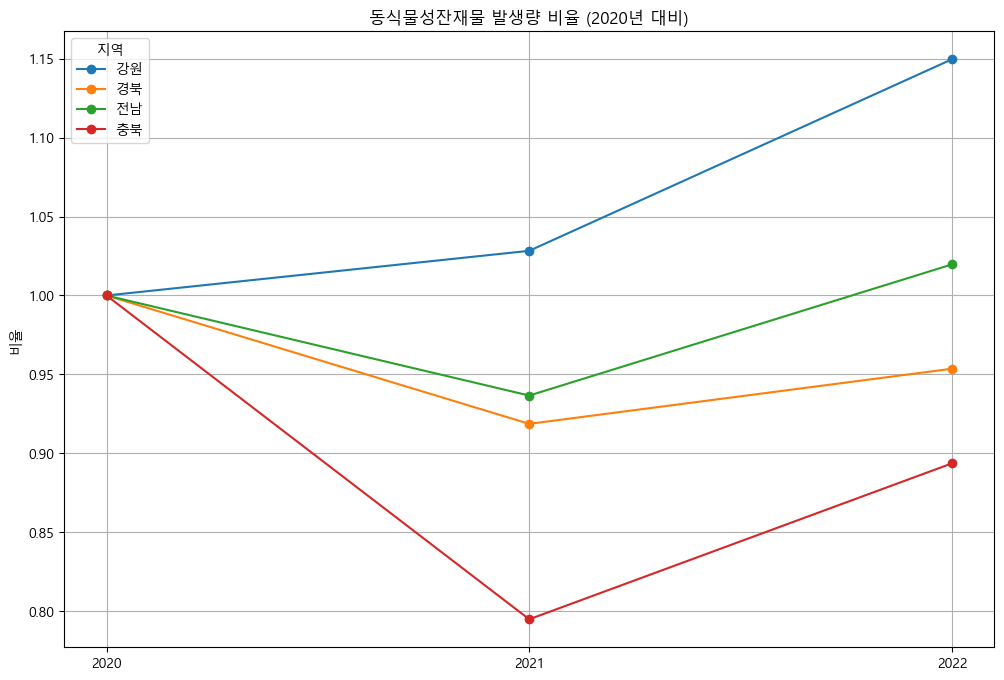

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# CSV 파일 경로
file_path = '../data/새 폴더/폐기물생산량.csv'

# 데이터 로드
data = pd.read_csv(file_path)

# 강원 지역 동식물성잔재물 데이터 필터링 및 비율 계산
def calculate_ratios(data, region, waste_type, years=[2020, 2021, 2022]):
    # 필터링
    data_filtered = data[(data['시도'] == region) & (data['폐기물 종류'] == waste_type) & (data['년도'].isin(years))]
    # 발생량 숫자로 변환
    data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')
    # 피벗 테이블 생성
    data_pivot = data_filtered.pivot(index='폐기물 종류', columns='년도', values='발생량')
    # 비율 계산
    data_pivot_ratio = data_pivot.div(data_pivot[2020], axis=0)
    return data_pivot_ratio

# 동식물성잔재물에 대한 모든 지역의 비율 계산
def calculate_all_regions_ratios(data, waste_type, years=[2020, 2021, 2022]):
    data_filtered = data[(data['폐기물 종류'] == waste_type) & (data['년도'].isin(years))]
    data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')
    data_pivot = data_filtered.pivot(index='시도', columns='년도', values='발생량')
    data_pivot_ratio = data_pivot.div(data_pivot[2020], axis=0)
    return data_pivot_ratio

# 비율 계산 및 그래프 출력
ratios = calculate_ratios(data, '강원', '동식물성잔재물')
print(ratios)

ratios_all_regions = calculate_all_regions_ratios(data, '동식물성잔재물')
print(ratios_all_regions)

plt.figure(figsize=(12, 8))
for region in ratios_all_regions.index:
    plt.plot(ratios_all_regions.columns, ratios_all_regions.loc[region], marker='o', label=region)

plt.title('동식물성잔재물 발생량 비율 (2020년 대비)')
plt.xlabel('')
plt.ylabel('비율')
plt.legend(title='지역')
plt.grid(True)
plt.xticks([2020, 2021, 2022])  # x축의 값을 1단위로 설정
plt.show()


In [ ]:
import pandas as pd
import folium
from geopy.distance import geodesic

# 데이터 로딩
file_path = '../data/exist500.csv'
data = pd.read_csv(file_path, encoding='CP949')
data = data.rename(columns={'Latitude': '위도', 'Longitude': '경도'})  # 좌표 열 이름 통일

# 시설 유형별 색상 지정 함수
def get_color(facility_type):
    return {
        '바이오가스화시설': 'green',
        '하수처리시설': 'blue',
        '음식물류폐기물처리시설': 'orange',
        '가축분뇨처리시설': 'red',
        '하수찌꺼기처리시설': 'purple'
    }.get(facility_type, 'gray')  # 기본값은 회색


# 지도 생성 및 저장 함수
def create_map(data, title):
    map_center = [data['위도'].mean(), data['경도'].mean()]
    map_obj = folium.Map(location=map_center, zoom_start=9, tiles='OpenStreetMap')
    for _, row in data.iterrows():
        folium.Marker(
            location=(row['위도'], row['경도']),
            popup=f"{row['구분']}: {row['시설명']}",
            icon=folium.Icon(color=get_color(row['구분']))
        ).add_to(map_obj)
    map_obj.save(f'../data/{title}.html')


In [7]:
import pandas as pd
import folium
from geopy.distance import geodesic

# 데이터 로딩
file_path = '../data/exist500.csv'
data = pd.read_csv(file_path, encoding='CP949')
data = data.rename(columns={'Latitude': '위도', 'Longitude': '경도'})  # 좌표 열 이름 통일

# 시설 유형별 색상 지정 함수
def get_color(facility_type):
    return {
        '바이오가스화시설': 'green',
        '하수처리시설': 'blue',
        '음식물류폐기물처리시설': 'orange',
        '가축분뇨처리시설': 'red',
        '하수찌꺼기처리시설': 'purple'
    }.get(facility_type, 'gray')  # 기본값은 회색

# 특정 유형의 시설만 지도에 그리는 함수
def create_specific_facility_map(data, facility_type, title):
    filtered_data = data[data['구분'] == facility_type]
    if filtered_data.empty:
        print(f"{facility_type}에 해당하는 데이터가 없습니다.")
        return

    map_center = [filtered_data['위도'].mean(), filtered_data['경도'].mean()]
    map_obj = folium.Map(location=map_center, zoom_start=9, tiles='OpenStreetMap')
    
    for _, row in filtered_data.iterrows():
        folium.Marker(
            location=(row['위도'], row['경도']),
            popup=f"{row['구분']}: {row['시설명']}",
            icon=folium.Icon(color=get_color(row['구분']))
        ).add_to(map_obj)
    
    map_obj.save(f'../data/{title}.html')
    print(f"{title}.html 파일이 생성되었습니다.")

# 시설 유형 목록
facility_types = ['바이오가스화시설', '하수처리시설', '음식물류폐기물처리시설', '가축분뇨처리시설', '하수찌꺼기처리시설']

# 각 시설 유형별로 지도 생성
for facility_type in facility_types:
    create_specific_facility_map(data, facility_type, facility_type + '_map')


바이오가스화시설_map.html 파일이 생성되었습니다.
하수처리시설_map.html 파일이 생성되었습니다.
음식물류폐기물처리시설_map.html 파일이 생성되었습니다.
가축분뇨처리시설_map.html 파일이 생성되었습니다.
하수찌꺼기처리시설_map.html 파일이 생성되었습니다.


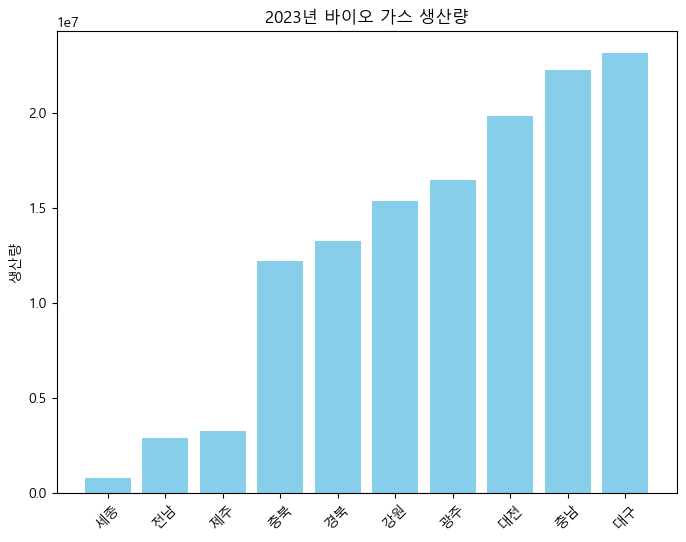

In [19]:
import pandas as pd

# 데이터를 로드합니다.
file_path = '../data/통합 문서1.csv'
data = pd.read_csv(file_path, encoding='utf-8')

# 데이터를 '년' 열 기준으로 내림차순 정렬합니다.
sorted_data = data.sort_values(by='년', ascending=True)

# 정렬된 데이터를 CSV 파일로 저장합니다.
sorted_data.to_csv('../data/sorted_biogas_data.csv', index=False, encoding='utf-8')

sorted_data.head(10)
import pandas as pd
import matplotlib.pyplot as plt

# 데이터를 '년' 열 기준으로 내림차순 정렬합니다.
sorted_data = data.sort_values(by='년', ascending=True)

# 필요한 열만 선택하여 상위 10개 행을 추출합니다.
selected_columns = sorted_data[['반입생산구분', '폐기물구분', '년', '시도']]
top_10 = selected_columns.head(10)

# 시각화합니다.
plt.figure(figsize=(8, 6))
plt.bar(top_10['시도'], top_10['년'], color='skyblue')
plt.xlabel('')
plt.ylabel('생산량')
plt.title('2023년 바이오 가스 생산량')
plt.xticks(rotation=45)
plt.show()

~\AppData\Local\Temp\ipykernel_25268\1226891545.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')
~\AppData\Local\Temp\ipykernel_25268\1226891545.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')


년도       2020      2021       2022
폐기물 종류                            
동식물성잔재물   0.0  2.829729  14.958025
년도  2020       2021       2022
시도                            
강원   0.0   2.829729  14.958025
경북   0.0  -8.128121  -4.638039
전남   0.0  -6.335767   1.967617
충북   0.0 -20.503162 -10.630331


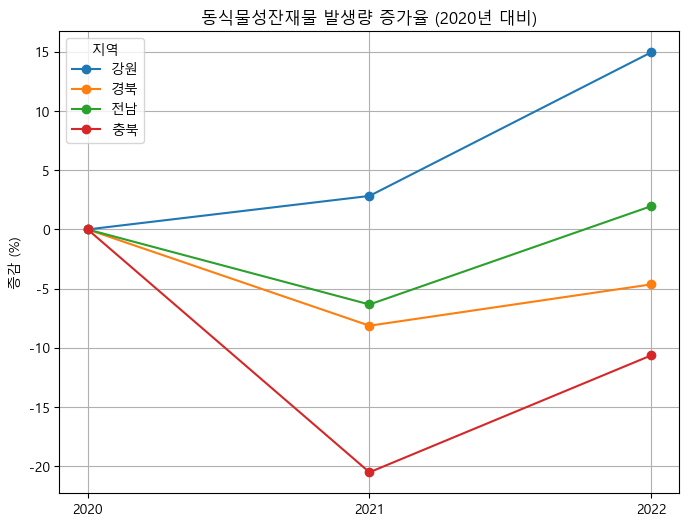

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# CSV 파일 경로
file_path = '../data/새 폴더/폐기물생산량.csv'

# 데이터 로드
data = pd.read_csv(file_path)

# 강원 지역 동식물성잔재물 데이터 필터링 및 증가율 계산
def calculate_growth_rate(data, region, waste_type, years=[2020, 2021, 2022]):
    # 필터링
    data_filtered = data[(data['시도'] == region) & (data['폐기물 종류'] == waste_type) & (data['년도'].isin(years))]
    # 발생량 숫자로 변환
    data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')
    # 피벗 테이블 생성
    data_pivot = data_filtered.pivot(index='폐기물 종류', columns='년도', values='발생량')
    # 증가율 계산
    data_pivot_growth = (data_pivot.div(data_pivot[2020], axis=0) - 1) * 100
    return data_pivot_growth

# 동식물성잔재물에 대한 모든 지역의 증가율 계산
def calculate_all_regions_growth_rate(data, waste_type, years=[2020, 2021, 2022]):
    data_filtered = data[(data['폐기물 종류'] == waste_type) & (data['년도'].isin(years))]
    data_filtered['발생량'] = pd.to_numeric(data_filtered['발생량'].str.replace(',', ''), errors='coerce')
    data_pivot = data_filtered.pivot(index='시도', columns='년도', values='발생량')
    data_pivot_growth = (data_pivot.div(data_pivot[2020], axis=0) - 1) * 100
    return data_pivot_growth

# 증가율 계산 및 그래프 출력
growth_rates = calculate_growth_rate(data, '강원', '동식물성잔재물')
print(growth_rates)

growth_rates_all_regions = calculate_all_regions_growth_rate(data, '동식물성잔재물')
print(growth_rates_all_regions)

plt.figure(figsize=(8, 6))
for region in growth_rates_all_regions.index:
    plt.plot(growth_rates_all_regions.columns, growth_rates_all_regions.loc[region], marker='o', label=region)

plt.title('동식물성잔재물 발생량 증가율 (2020년 대비)')
plt.xlabel('')
plt.ylabel('증감 (%)')
plt.legend(title='지역')
plt.grid(True)
plt.xticks([2020, 2021, 2022])  # x축의 값을 1단위로 설정
plt.show()
